## Imports

In [1]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import inspect
import math
import torch
import torch.nn as nn
import random
import legproject_important as leg
from sklearn.preprocessing import MinMaxScaler
from collections import Counter
from copy import deepcopy
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import os

import avin as pa
from IPython.display import display, HTML
display(HTML("""
<style>
.container { width:100% !important; }
.output { max-width:100% !important; }
</style>
"""))

## Data_Frame

## Create_LegManager

## PointsA_Accepted

In [4]:

def prepare_dataframe(n=2500, seed=42):

    np.random.seed(seed)

    t = np.arange(n)

    
    temperature = (22+ 5 * np.sin(2 * np.pi * t / 200)
        + 1.5 * np.sin(2 * np.pi * t / 37)
        + np.random.normal(0, 0.5, n))

    
    humidity = (
        55- 0.8 * (temperature - 22)
        + 4 * np.sin(2 * np.pi * t / 120)
        + np.random.normal(0, 1.2, n)
    )

   
    pressure = (
        1013
        + 6 * np.sin(2 * np.pi * t / 300)
        + 2 * np.sin(2 * np.pi * t / 73)
        + np.random.normal(0, 0.8, n)
    )

   
    energy = (
        100
        + 4.5 * temperature
        - 0.7 * humidity
        + 0.08 * pressure
        + 8 * np.sin(2 * np.pi * t / 90)
        + 5 * np.sin(2 * np.pi * t / 27)
        + np.random.normal(0, 2, n)
    )

    df = pd.DataFrame({
        "temperature": temperature,
        "humidity": humidity,
        "pressure": pressure,
        "energy": energy
    })

    return df

In [17]:
Prepare_PriceDf = prepare_dataframe()

display(Prepare_PriceDf.head())
print("Shape:", Prepare_PriceDf.shape)

,temperature,humidity,pressure,energy
0,22.248357,55.486050,1012.660992,245.741639
1,22.341423,56.098027,1012.934853,244.257392
2,23.137507,54.110539,1012.157326,252.078204
3,23.963599,53.320175,1013.623378,256.678827
4,23.451919,53.367931,1014.763376,254.238204


Shape: (2500, 4)


## F_Model

In [18]:

F_Model = [
    "temperature",
    "humidity",
    "pressure",
    "energy"
]

## T_Model

In [19]:

T_Model = "energy"

TARGET_IDX = F_Model.index(T_Model)

## PositionalEncoding

In [20]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len].to(x.dtype)

## MultiHeadAttention

In [21]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.1):
        super().__init__()
        assert d_model % nhead == 0
        self.nhead = nhead
        self.head_dim = d_model // nhead
        self.scale = 1.0 / math.sqrt(self.head_dim)
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, C = x.shape
        q = self.q_proj(x).view(B, T, self.nhead, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.nhead, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.nhead, self.head_dim).transpose(1, 2)

        attn_scores = (q @ k.transpose(-2, -1)) * self.scale
        if mask is None:
            mask = torch.tril(torch.ones(T, T, device=x.device)).bool()
        attn_scores = attn_scores.masked_fill(~mask, torch.finfo(attn_scores.dtype).min)
        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        out = attn_weights @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out)

## TransformerBlock

In [22]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model=d_model, nhead=nhead, dropout=dropout)
        self.dropout1 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * d_model, d_model)
        )
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = x + self.dropout1(self.attn(self.norm1(x), mask))
        x = x + self.dropout2(self.ff(self.norm2(x)))
        return x

## FinancialTransformer

In [23]:
class FinancialTransformer(nn.Module):
    def __init__(self, input_dim, output_dim=1, pred_len=5, d_model=128, nhead=4, num_layers=4, dropout=0.1):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.pred_len = pred_len

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout)
        )
        self.pos_encoding = PositionalEncoding(d_model)
        self.blocks = nn.ModuleList([TransformerBlock(d_model, nhead, dropout) for _ in range(num_layers)])
        self.final_norm = nn.LayerNorm(d_model)

        self.output_proj = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, pred_len * output_dim)
        )
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x, mask=None):
        x = self.input_proj(x)
        x = self.pos_encoding(x)
        for block in self.blocks:
            x = block(x, mask)
        x = self.final_norm(x)
        x = x[:, -1]
        out = self.output_proj(x)
        out = out.view(x.shape[0], self.pred_len, self.output_dim)
        return out

## FinancialDataset

In [24]:
class FinancialDataset(Dataset):
    def __init__(self, data_array, seq_len, pred_len=1, target_idx=0):
        self.data = data_array
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.target_idx = target_idx
        
    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1
    
    def __getitem__(self, idx):
        x = self.data[idx:idx + self.seq_len]
        y = self.data[idx + self.seq_len:idx + self.seq_len + self.pred_len, self.target_idx:self.target_idx+1]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

## Scale_features

In [25]:
def scale_features(PriceDf, F_Model, scaler=None, fit=False):
    cols_to_scale = [c for c in F_Model if c != 'direction']
    scaled_data = PriceDf[F_Model].copy()
    
    if fit:
        scaler = StandardScaler()
        scaled_data[cols_to_scale] = scaler.fit_transform(PriceDf[cols_to_scale])
    else:
        scaled_data[cols_to_scale] = scaler.transform(PriceDf[cols_to_scale])
        
    return scaled_data.values, scaler

## Data_Preprocessing

In [26]:
if __name__ == "__main__":
    train_size = int(len(Prepare_PriceDf) * 0.70)
    val_size = int(len(Prepare_PriceDf) * 0.15)
    
    train_PriceDf = Prepare_PriceDf.iloc[:train_size].copy()
    
    val_PriceDf = Prepare_PriceDf.iloc[
        train_size:train_size + val_size
    ].copy()
    
    test_PriceDf = Prepare_PriceDf.iloc[
        train_size + val_size:
    ].copy()

##  Feature_Scaling

In [27]:
# if __name__ == "__main__":
#     # scaler = StandardScaler()
#     scaler = MinMaxScaler(feature_range=(0, 1))
#     train_scaled, scaler = scale_features(train_PriceDf, F_Model, fit=True)
#     val_scaled, _ = scale_features(val_PriceDf, F_Model, scaler=scaler, fit=False)
#     test_scaled, _ = scale_features(test_PriceDf, F_Model, scaler=scaler, fit=False)

In [28]:
if __name__ == "__main__":
    train_scaled, scaler = scale_features(
    train_PriceDf,
    F_Model,
    fit=True
)

    val_scaled, _ = scale_features(
        val_PriceDf,
        F_Model,
        scaler=scaler,
        fit=False
    )
    
    test_scaled, _ = scale_features(
        test_PriceDf,
        F_Model,
        scaler=scaler,
        fit=False
    )

## Dataset_Preparation

In [29]:
if __name__ == "__main__":
    seq_len = 8
    # seq_len = min(16, len(train_scaled) // 10)
    batch_size = 64
    pred_len = 1
    
    input_dim = len(F_Model)
    output_dim = 1
    d_model = 128
    nhead = 4
    num_layers = 2
    dropout = 0.1
    
    train_dataset = FinancialDataset(train_scaled, seq_len, pred_len, target_idx=TARGET_IDX)
    val_dataset = FinancialDataset(val_scaled, seq_len, pred_len, target_idx=TARGET_IDX)
    test_dataset = FinancialDataset(test_scaled, seq_len, pred_len, target_idx=TARGET_IDX)

## DataLoader

In [30]:
if __name__ == "__main__":
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

## Device

In [31]:
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Transformer Model

In [32]:
if __name__ == "__main__":
    model = FinancialTransformer(
    input_dim=input_dim,
    output_dim=output_dim,
    pred_len=pred_len,
    d_model=d_model,
    nhead=nhead,
    num_layers=num_layers,
    dropout=dropout
    ).to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    loss_fn = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-5)


In [33]:
print("train_scaled:", train_scaled.shape)
print("val_scaled:", val_scaled.shape)
print("test_scaled:", test_scaled.shape)

train_scaled: (1750, 4)
val_scaled: (375, 4)
test_scaled: (375, 4)


## <div style='color:green;'> Model_Training</div>

In [34]:
if __name__ == "__main__":
    train_losses = []
    val_losses = []
    start_epochs = 0
    end_epochs = 150
    for epoch in range(start_epochs, end_epochs):
        model.train()
        train_loss = 0.0
        for batch_idx, (x, y) in enumerate(train_loader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            predictions = model(x)
            loss = loss_fn(predictions, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
            
            # if batch_idx % 100 == 0:
            #     print(f'Epoch {epoch+1}, Batch {batch_idx}, Loss: {loss.item():.6f}')
        
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                predictions = model(x)
                loss = loss_fn(predictions, y)
                val_loss += loss.item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        scheduler.step(avg_val_loss)
        
        epochs_total = end_epochs - start_epochs    
        print(f'Epoch {epoch+1}/{epochs_total} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | LR: {optimizer.param_groups[0]["lr"]:.6f}')



Epoch 1/150 | Train Loss: 0.380867 | Val Loss: 0.106973 | LR: 0.000100
Epoch 2/150 | Train Loss: 0.151270 | Val Loss: 0.071882 | LR: 0.000100
Epoch 3/150 | Train Loss: 0.114223 | Val Loss: 0.059089 | LR: 0.000100
Epoch 4/150 | Train Loss: 0.102887 | Val Loss: 0.069653 | LR: 0.000100
Epoch 5/150 | Train Loss: 0.093994 | Val Loss: 0.057970 | LR: 0.000100
Epoch 6/150 | Train Loss: 0.086712 | Val Loss: 0.056982 | LR: 0.000100
Epoch 7/150 | Train Loss: 0.081725 | Val Loss: 0.054099 | LR: 0.000100
Epoch 8/150 | Train Loss: 0.080857 | Val Loss: 0.054224 | LR: 0.000100
Epoch 9/150 | Train Loss: 0.078137 | Val Loss: 0.053962 | LR: 0.000100
Epoch 10/150 | Train Loss: 0.078916 | Val Loss: 0.056513 | LR: 0.000100
Epoch 11/150 | Train Loss: 0.075494 | Val Loss: 0.053332 | LR: 0.000100
Epoch 12/150 | Train Loss: 0.073145 | Val Loss: 0.055128 | LR: 0.000100
Epoch 13/150 | Train Loss: 0.074160 | Val Loss: 0.052168 | LR: 0.000100
Epoch 14/150 | Train Loss: 0.069701 | Val Loss: 0.055136 | LR: 0.000100
E

In [37]:
start = np.array(train_scaled[-seq_len:], copy=True)

gen = generate_time_series(
    model=model,
    start=start,
    device=device
)

gen = np.array(gen, copy=True)
gen_saved = gen.copy()

print("START:")
print(start)

print("GEN:", gen_saved)

START:
[[-1.12549529  0.50569006 -1.83542606 -0.76666005]
 [-0.93257148  0.68311308 -1.78694267 -0.8134635 ]
 [-1.1717834   0.61335551 -1.66343589 -0.98935293]
 [-0.98231378 -0.0034542  -1.60897345 -0.85023916]
 [-0.85884215  0.34072559 -1.57155544 -0.74134046]
 [-0.90701431  0.89551419 -1.27039291 -1.03860379]
 [-0.94339072  0.40028029 -1.40143585 -0.80295527]
 [-0.83955545  0.13049845 -1.29604715 -0.99248986]]
GEN: [-0.9218934]


## generate_time_series

In [38]:
def generate_time_series(model, start, device): 
    model.eval()
    current_seq = torch.tensor(start, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
            pred = model(current_seq)   
            next_val = pred[:, 0, 0]    
    return next_val.cpu().numpy()

In [39]:
gen = generate_time_series(
    model=model,
    start=start,
    device=device
)

gen = np.array(gen, copy=True)

gen_saved = gen.copy()

print("GEN:", gen_saved)

GEN: [-0.9218934]


## Validation Phase

In [40]:
if __name__ == "__main__":
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            predictions = model(x)
            loss = loss_fn(predictions, y)
            test_loss += loss.item()
    print(f"Test Loss: {test_loss / len(test_loader):.6f}")


Test Loss: 0.045065


## Plot

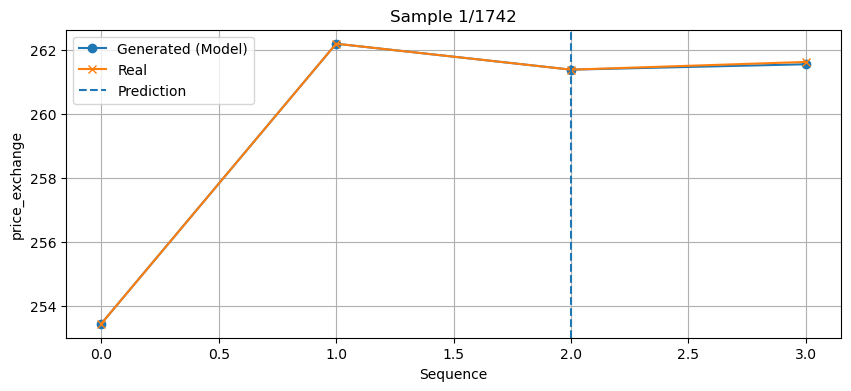

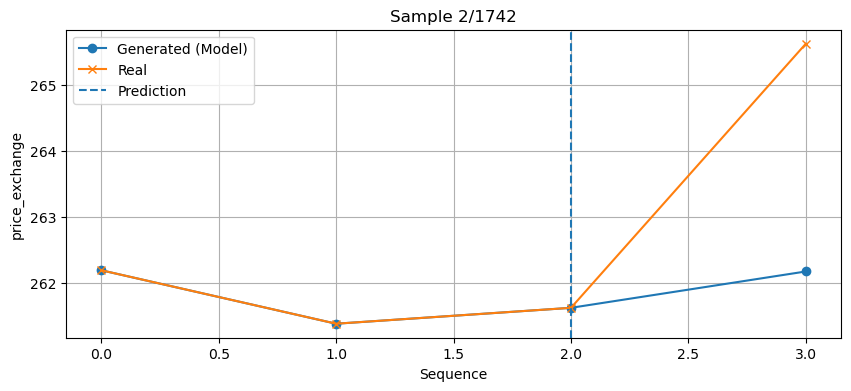

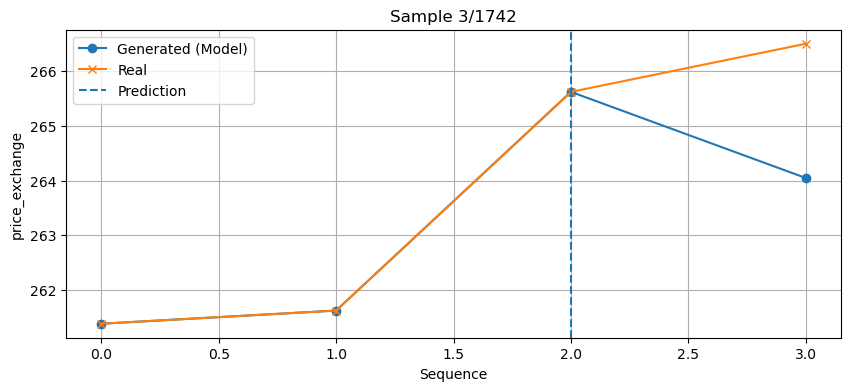

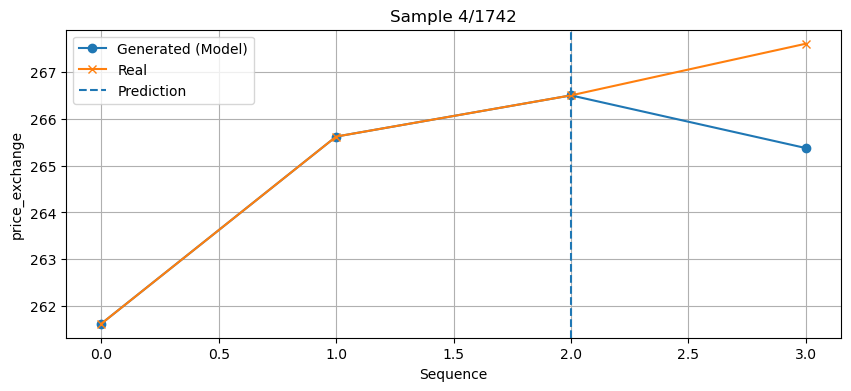

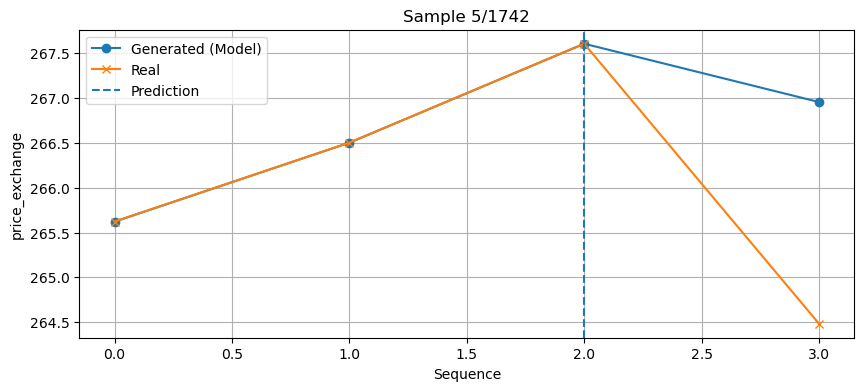

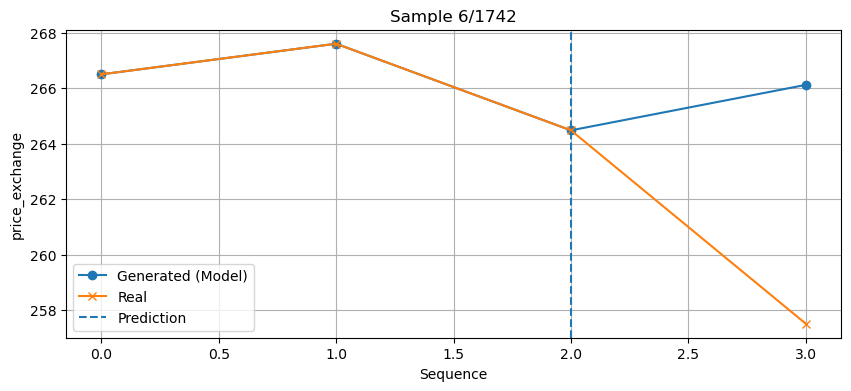

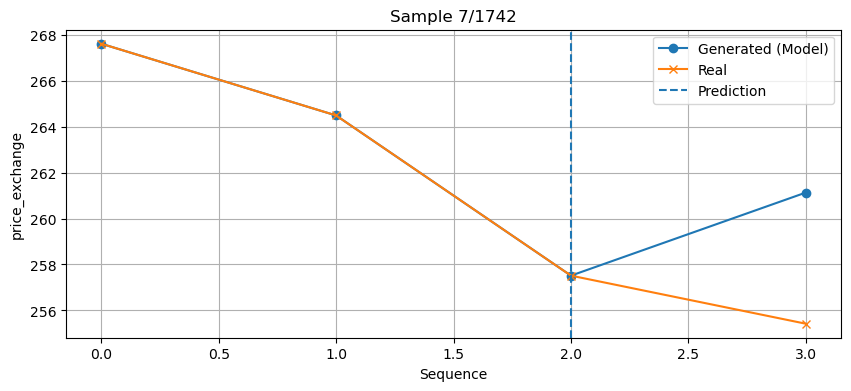

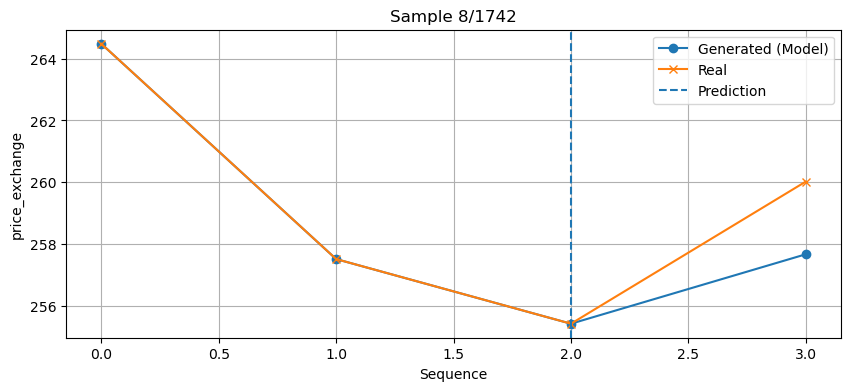

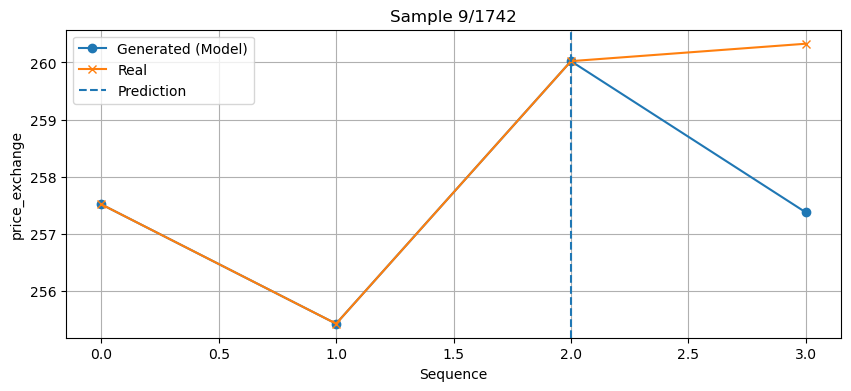

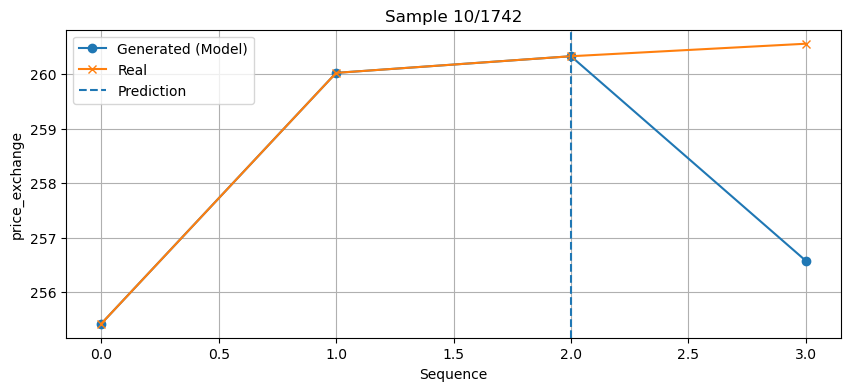

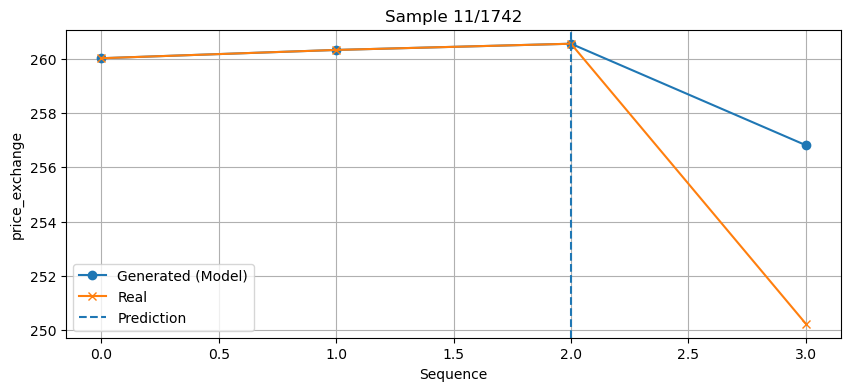

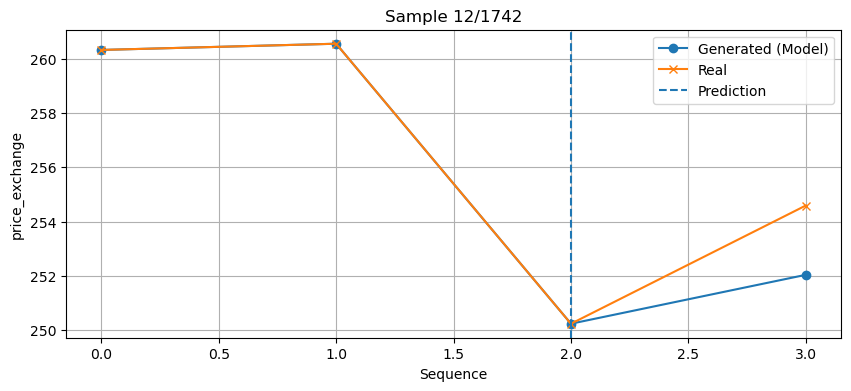

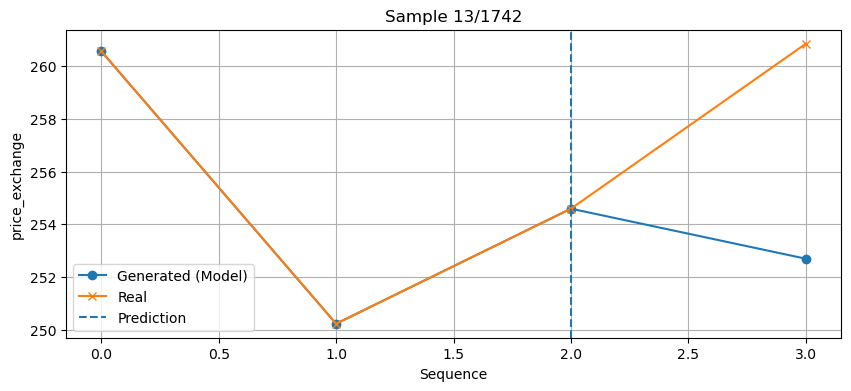

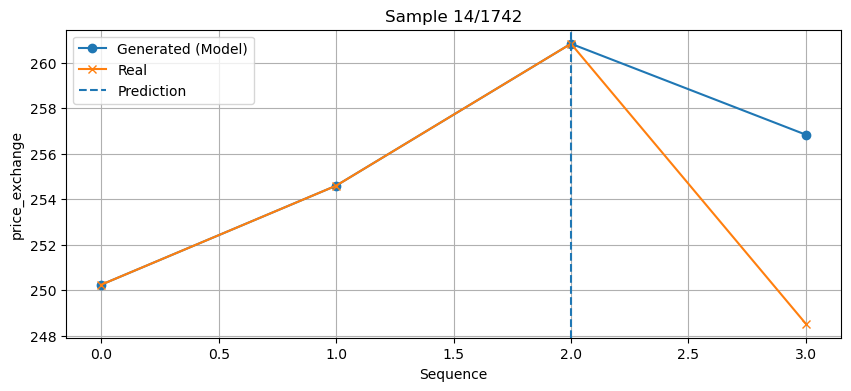

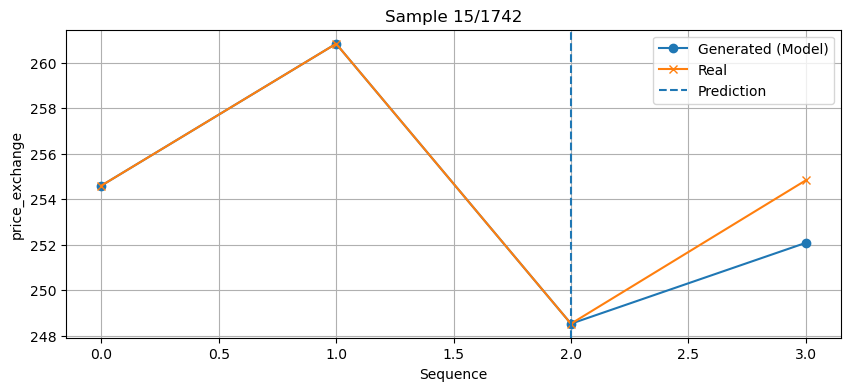

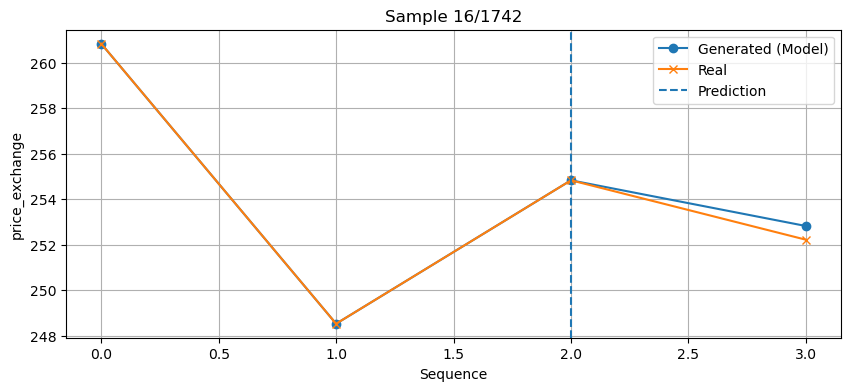

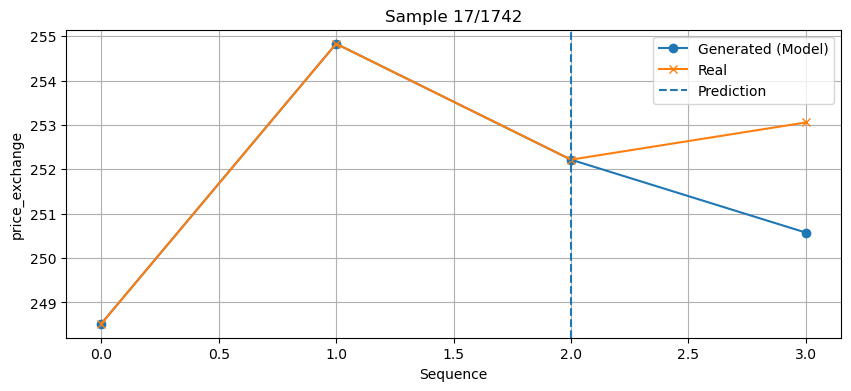

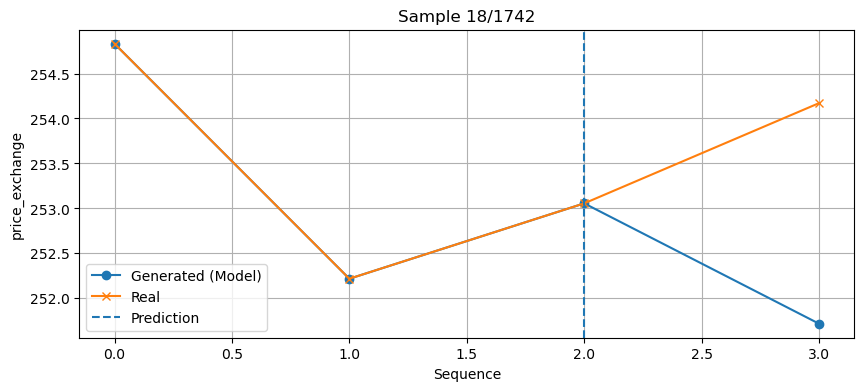

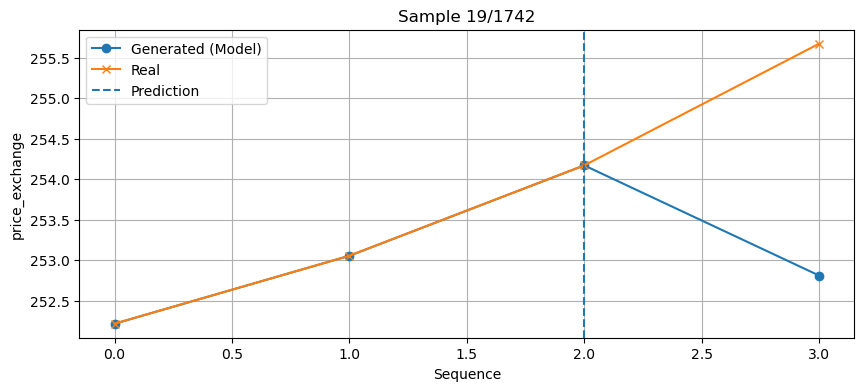

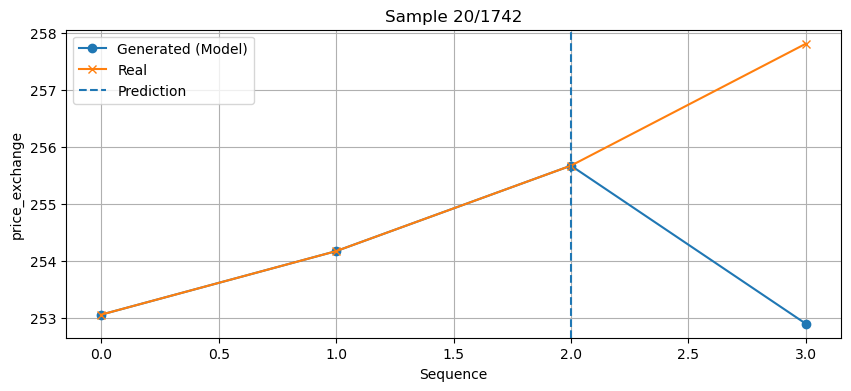

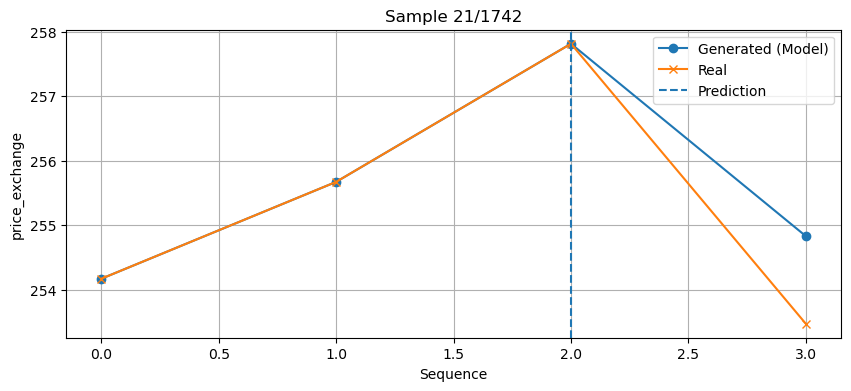

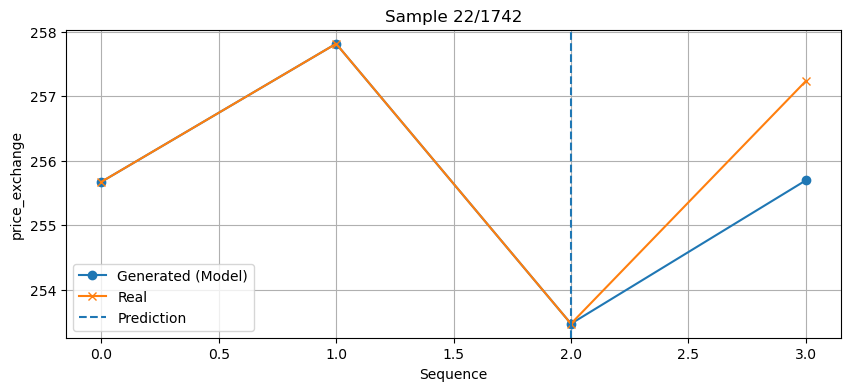

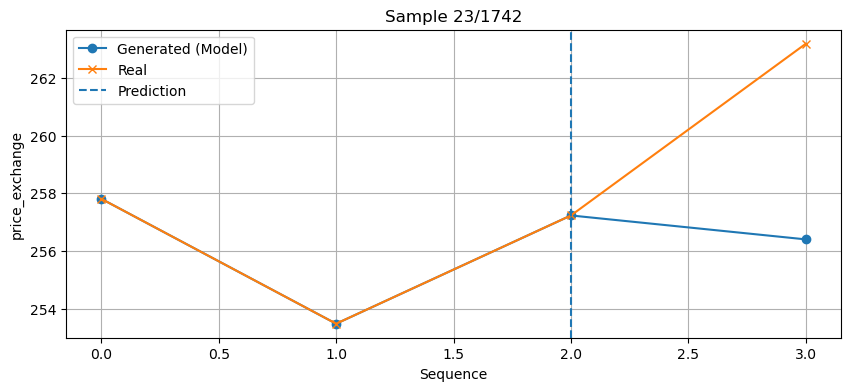

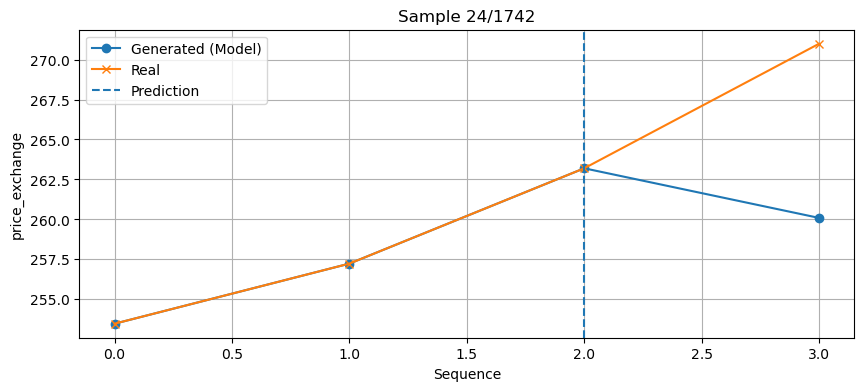

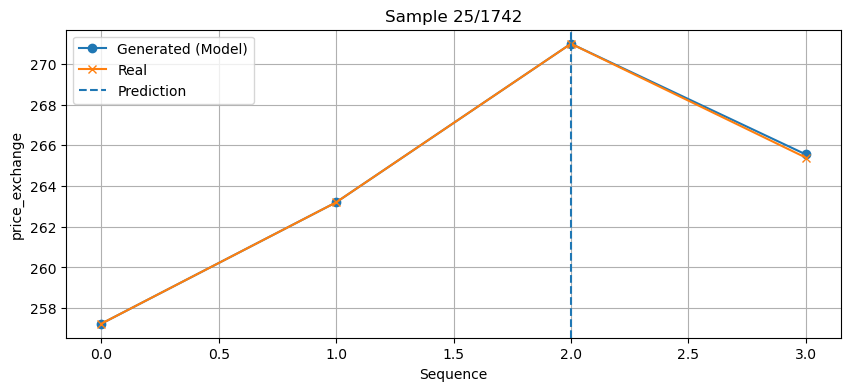

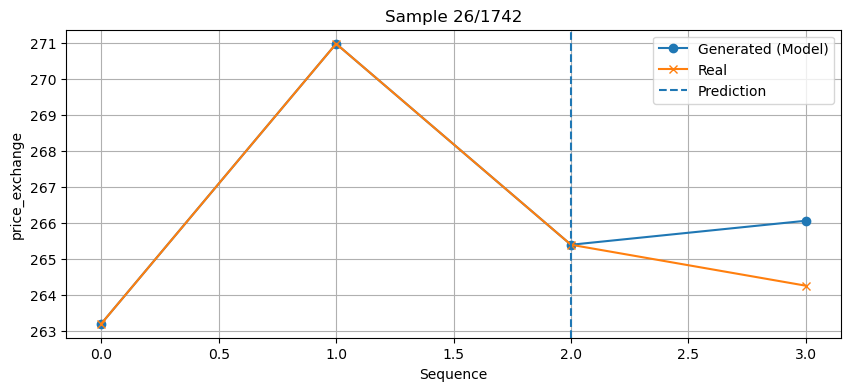

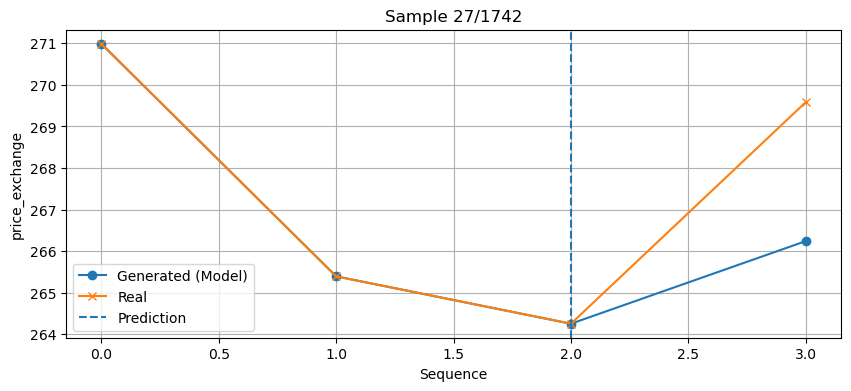

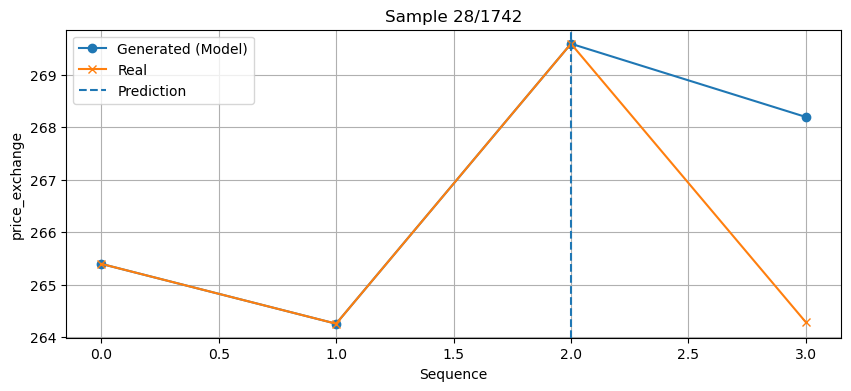

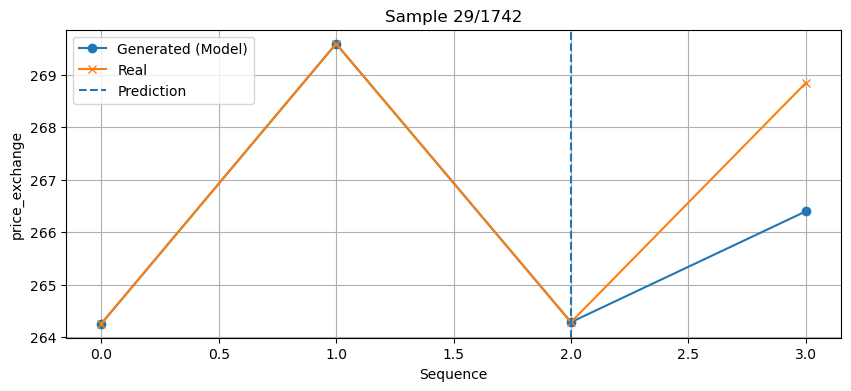

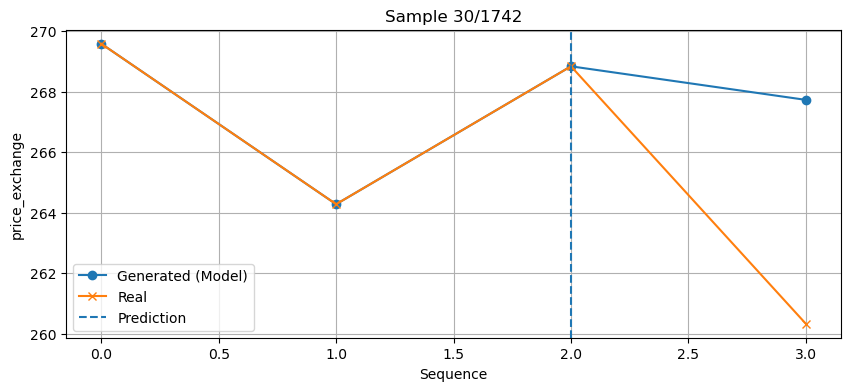

In [41]:
if __name__ == "__main__":

    # d = deepcopy(train_scaled)
    d = deepcopy(train_scaled)

    price_idx = TARGET_IDX
    model.eval()

    lookbackLength = seq_len
    generateSeq = pred_len
    commonData = min(3, lookbackLength)

    generatedAndReal = []

    max_samples = len(d) - lookbackLength - generateSeq + 1

    if max_samples <= 0:

        print(
            f"Not enough data: "
            f"data={len(d)}, "
            f"lookback={lookbackLength}, "
            f"generate={generateSeq}"
        )

    else:

        for i in range(30):

            startIndex = i

            desiredData = d[
                startIndex:
                startIndex + lookbackLength
            ]

            realData = d[
                startIndex + lookbackLength:
                startIndex + lookbackLength + generateSeq
            ]

            if len(desiredData) != lookbackLength:
                continue

            if len(realData) != generateSeq:
                continue

            #

            gen = generate_time_series(
                model=model,
                start=desiredData,
                device=device
            ).flatten()

            # Real target
            r = realData[:, price_idx]

            # آخرین چند مقدار واقعی قبل از prediction
            common = desiredData[
                -commonData:,
                price_idx
            ]

           

            gen_real = (
                gen * scaler.scale_[price_idx]
                + scaler.mean_[price_idx]
            )

            r_real = (
                r * scaler.scale_[price_idx]
                + scaler.mean_[price_idx]
            )

            common_real = (
                common * scaler.scale_[price_idx]
                + scaler.mean_[price_idx]
            )

            

            g = np.concatenate([
                common_real,
                gen_real
            ])

            

            r_plot = np.concatenate([
                common_real,
                r_real
            ])

            generatedAndReal.append({
                "generated": g,
                "real": r_plot
            })

           

            plt.figure(figsize=(10, 4))

            plt.plot(
                g,
                marker="o",
                label="Generated (Model)"
            )

            plt.plot(
                r_plot,
                marker="x",
                label="Real"
            )

            plt.axvline(
                commonData - 1,
                linestyle="--",
                label="Prediction"
            )

            plt.title(
                f"Sample {i + 1}/{max_samples}"
            )

            plt.xlabel("Sequence")
            plt.ylabel("price_exchange")

            plt.legend()
            plt.grid(True)

            plt.show()
            plt.close()

## Area Finder

In [42]:
def area_finder(manual_real, manual_gen):
    mean_val = d[:, price_idx].mean()
    std_val = d[:, price_idx].std()
   
    z_r = get_zone_name(manual_real, mean_val)
    z_g = get_zone_name(manual_gen, mean_val)

    dist = abs(manual_real - manual_gen)
    score = (1 / (1 + dist)) * 100

    return {
        "Real": manual_real,
        "Gen": manual_gen,
        "Distance": dist,
        "Score": score,
        "z_r": z_r,
        "z_g": z_g
    }

In [43]:
def get_zone_score(centerVal, val, mean_val, borderCoef=1):
    upper = abs(mean_val) * borderCoef
    lower = abs(mean_val) * -borderCoef

    if val >= upper:
        return 6
    elif centerVal < val < upper:
        return 5
    elif lower < val < centerVal:
        return 1
    elif val <= lower:
        return 2
    else:
        return 3


if __name__ == "__main__":

    mean_ = np.mean(np.abs(train_scaled[:, 0]))
    print(mean_)

    zoneLoss = []
    zoneResult = []

    candleNumber = 1
    borderCoef = 3

    centerIndex = commonData - 2 + candleNumber
    candleNumber = commonData - 1 + candleNumber

    for element in generatedAndReal:

        generated = element["generated"]
        real = element["real"]

        centerVal = generated[centerIndex]

        generatedVal = generated[candleNumber]
        realVal = real[candleNumber]

        gs = get_zone_score(
            centerVal,
            generatedVal,
            mean_,
            borderCoef
        )

        rs = get_zone_score(
            centerVal,
            realVal,
            mean_,
            borderCoef
        )

        zoneLoss.append(
            abs(rs - gs)
        )

        zoneResult.append({
            "generated": generatedVal,
            "real": realVal,
            "generated_zone": gs,
            "real_zone": rs,
            "zone_loss": abs(rs - gs)
        })

    counterDictionary = Counter(zoneLoss)

    acc = (
        counterDictionary.get(0, 0)
        / len(zoneLoss)
        if len(zoneLoss) > 0
        else 0
    )

    print("Acc:", acc)

0.879340488230249
Acc: 1.0


## Target

In [44]:
if __name__ == "__main__":
    target_llm = {
    T_Model: gen_saved
    }
    
    target = pd.DataFrame(target_llm)
    display(target)

,energy
0,-0.921893


In [45]:
real = realData[:, price_idx]

target = pd.DataFrame({
    "Real": real,
    "Generated": gen_saved,
})

target["Error"] = target["Generated"] - target["Real"]
target["Abs_Error"] = np.abs(target["Error"])

display(target)
target.to_csv(f"{T_Model}.csv", index=False)

,Real,Generated,Error,Abs_Error
0,0.887661,-0.921893,-1.809555,1.809555


In [46]:
target = pd.read_csv(f"{T_Model}.csv")
display(target)

,Real,Generated,Error,Abs_Error
0,0.887661,-0.921893,-1.809555,1.809555
